# Capstone Submission File


In [1]:
#imports
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from scipy.stats import norm, rankdata, qmc
import matplotlib.pyplot as plt

In [2]:
# Load data from all funcitons
#f1-8
f1x = np.load("./function_1/updated_inputs.npy")
f1y = np.load("./function_1/updated_outputs.npy")

f2x = np.load("./function_2/updated_inputs.npy")
f2y = np.load("./function_2/updated_outputs.npy")

f3x = np.load("./function_3/updated_inputs.npy")
f3y = np.load("./function_3/updated_outputs.npy")

f4x = np.load("./function_4/updated_inputs.npy")
f4y = np.load("./function_4/updated_outputs.npy")

f5x = np.load("./function_5/updated_inputs.npy")
f5y = np.load("./function_5/updated_outputs.npy")

f6x = np.load("./function_6/updated_inputs.npy")
f6y = np.load("./function_6/updated_outputs.npy")

f7x = np.load("./function_7/updated_inputs.npy")
f7y = np.load("./function_7/updated_outputs.npy")

f8x = np.load("./function_8/updated_inputs.npy")
f8y = np.load("./function_8/updated_outputs.npy")

### Setting up Gaussian Process regressor

In [3]:
def GP(x, y):
    kernel = ( #improving noise threshold
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-4, 1e2))
    + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e1))
    )
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
        )
    
    gpr = gpr.fit(x, y)
    return gpr


### Formulas for Acquisition Functions:
UCB:

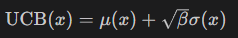


EI:

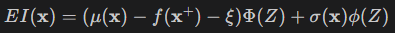


PI:

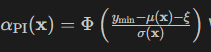


In [4]:
# Defining acquisition functions to use the the projeft

#Upper confidence bounds:
#   Plan to use this in the first 3 weeks to improve my understanding of the function.
def UCB(X_new, gp_ucb, beta):
    #predict mean and std:
    mu, sigma = gp_ucb.predict(X_new, return_std=True)
    return mu + (beta * sigma)

#Expected Imrpovement:
#   I plan to use this for the mid term of the challange, this is to balance exploration and exploitation
def EI():
    pass

#Probability Improvement
#   This acquisition function is focused on exploitation, I am aiming to use this for weeks 10-13 to find optimal values. 
def PI():
    pass

In [5]:
def bounds(X, padding=0.0):
    """
    Create upper and lower bounds from data using padding. 
    """
    X = np.asarray(X)

    lower = X.min(axis=0)
    upper = X.max(axis=0)

    width = upper - lower
    width = np.where(width == 0, 1.0, width)

    lower = lower - padding * width
    upper = upper + padding * width

    return list(zip(lower, upper))

def make_grid(bounds, n_points=100):
    """
    Generate a full Cartesian grid of candidate points for an arbitrary
    number of dimensions.

    bounds: list of (low, high) tuples for each dimension
    n_points: number of points along each dimension
    """
    axes = [np.linspace(low, high, n_points) for (low, high) in bounds]
    # Use 'ij' so the shape aligns with the order of bounds
    grids = np.meshgrid(*axes, indexing='ij')
    # Flatten each grid and stack them into columns
    candidates = np.column_stack([g.ravel() for g in grids])
    return candidates

In [6]:
print(make_grid(bounds=bounds(f1x, padding=0.05), n_points=50))
print(make_grid(bounds=bounds(f1x, padding=0.1), n_points=50))

[[0.04243812 0.03866401]
 [0.04243812 0.05664958]
 [0.04243812 0.07463515]
 ...
 [0.92395896 0.88398573]
 [0.92395896 0.9019713 ]
 [0.92395896 0.91995687]]
[[ 0.00236899 -0.00139475]
 [ 0.00236899  0.01822587]
 [ 0.00236899  0.03784649]
 ...
 [ 0.96402809  0.9207744 ]
 [ 0.96402809  0.94039502]
 [ 0.96402809  0.96001564]]


In [7]:
#using QMC to make candidate points, this creates x random valyes in the search space rather than specific distributions:
def make_candidates(domain_bounds,n_candidates=50_000,seed=42):
    dimensions = len(domain_bounds)

    sampler = qmc.Sobol(
        d=dimensions,
        scramble=True,
        seed=seed
    )

    exponent = int(np.ceil(np.log2(n_candidates)))

    unit_candidates = sampler.random_base2(
        m=exponent
    )[:n_candidates]

    lower = np.array(
        [bound[0] for bound in domain_bounds]
    )

    upper = np.array(
        [bound[1] for bound in domain_bounds]
    )

    return qmc.scale(
        unit_candidates,
        lower,
        upper
    )

In [9]:
print(make_candidates(domain_bounds=bounds(f1x, padding=0.1), n_candidates=500, seed=42))

[[4.16872407e-01 7.81547077e-01]
 [9.27079983e-01 2.97998001e-01]
 [5.45256248e-01 5.73369359e-01]
 [3.60725696e-02 2.40915339e-02]
 [2.31308555e-01 6.13617177e-01]
 [6.20487069e-01 2.23963169e-01]
 [7.31641776e-01 8.80019962e-01]
 [3.41843809e-01 4.39644573e-01]
 [2.48973452e-01 4.93931033e-01]
 [8.20696953e-01 1.04320978e-01]
 [7.21603616e-01 7.59409608e-01]
 [1.49033104e-01 3.19107512e-01]
 [7.37986145e-02 9.01305598e-01]
 [5.26371299e-01 4.17800474e-01]
 [8.95721883e-01 6.94022746e-01]
 [4.44415328e-01 1.44818213e-01]
 [4.65257857e-01 6.66929041e-01]
 [8.56097659e-01 1.72175268e-01]
 [5.05437051e-01 9.31916175e-01]
 [1.13514543e-01 3.86455691e-01]
 [1.58722664e-01 7.28290633e-01]
 [6.70591642e-01 3.49964985e-01]
 [8.11150455e-01 5.21528566e-01]
 [2.99842350e-01 7.74594994e-02]
 [3.20899473e-01 8.48927805e-01]
 [7.71369626e-01 4.70528864e-01]
 [6.41347024e-01 6.41182849e-01]
 [1.91665071e-01 1.97069829e-01]
 [2.65141491e-02 5.46247002e-01]
 [5.96135234e-01 5.14199365e-02]
 [9.367888

[(np.float64(0.08250725182080587), np.float64(0.8838898288181171)),
 (np.float64(0.07872277794971883), np.float64(0.879898104984359))]

### Utilising Acquisition function to chose next point:

In [13]:
def main(x, y, pad, points, beta, scale=1.0):
    #train model
    y_scaled = y * scale
    gp = GP(x, y_scaled)

    #Candidate generation
    #creating candidate grid with 2.5% padding on each side
    #This increases search space by roughly 5%
    candidates = make_candidates(domain_bounds=bounds(x, padding=pad), n_candidates=points) 

    #calc ucb:
    ucb = UCB(X_new=candidates, gp_ucb=gp, beta=beta)

    #make selection off ucb:
    return candidates[np.argmax(ucb)]
    


In [14]:
#def beta
b = 3

In [15]:
f1y_ranked = rankdata(f1y) / len(f1y)
main(f1x, f1y_ranked, pad=0.0, points=5000000, beta=b)

c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([0.71932886, 0.72310229])

In [ ]:
main(f2x, f2y, pad=0.0, points=5000000, beta=b)

array([0.8446013 , 0.92656036])

In [ ]:
main(f3x, f3y, pad=0.0, points=5000000, beta=b)

c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([0.96267788, 0.65733265, 0.58296529])

In [ ]:
main(f4x, f4y, pad=0.0, points=5000000, beta=b)

c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


array([0.38364268, 0.38886638, 0.40583141, 0.44126017])

In [ ]:
main(f5x, f5y, pad=0.0, points=5000000, beta=b)

c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([0.836478  , 0.86254031, 0.87948418, 0.77830004])

In [ ]:
main(f6x, f6y, pad=0.0, points=5000000, beta=b)

c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([0.21673597, 0.65938206, 0.0165229 , 0.961656  , 0.0049115 ])

In [ ]:
main(f7x, f7y, pad=0.0, points=5000000, beta=b)

c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([0.05789554, 0.437824  , 0.55619613, 0.073659  , 0.34284757,
       0.7110369 ])

In [ ]:
main(f8x, f8y, pad=0.0, points=5000000, beta=b)

c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
c:\Users\Luams\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([0.00907698, 0.0034195 , 0.02292868, 0.90298577, 0.986902  ,
       0.99024381, 0.03590888, 0.041956  ])